In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# ----------------------------
# Parameters from assignment
# ----------------------------
h = 35.0          # water depth [m]
H = 150.0         # tower height above water [m]
L = h + H         # total length [m]

D = 8.0           # diameter [m]
t = 0.1           # wall thickness [m]

M_tip = 1000e3    # RNA mass: 1000 tons -> 1e6 kg
J_tip = 1.6e9     # RNA mass moment of inertia [kg m^2]

# Material (assumed, not explicitly given numerically in the PDF)
E = 210e9         # Young's modulus steel [Pa]
rho = 7850.0      # density steel [kg/m^3]

# Hollow circular section properties
R_o = D / 2.0
R_i = R_o - t

A = np.pi * (R_o**2 - R_i**2)                 # area [m^2]
I = (np.pi / 4.0) * (R_o**4 - R_i**4)         # second moment [m^4]
mu = rho * A                                   # mass per length [kg/m]

print("Section A [m^2] =", A)
print("Section I [m^4] =", I)
print("Mass/length mu [kg/m] =", mu)

# ----------------------------
# FEM discretization
# Euler-Bernoulli beam, 2 DOF per node: w, theta
# ----------------------------
Ne = 120                      # number of elements (increase for smoother modes)
Nn = Ne + 1                   # number of nodes
Le = L / Ne                   # element length

ndof = 2 * Nn                 # total DOFs

K = np.zeros((ndof, ndof))
M = np.zeros((ndof, ndof))

def beam_element_matrices(EI, mu, l):
    """
    Euler–Bernoulli beam element (Hermite shape functions)
    DOFs: [w1, th1, w2, th2]
    """
    # Stiffness
    ke = (EI / l**3) * np.array([
        [ 12,   6*l, -12,   6*l],
        [ 6*l, 4*l**2, -6*l, 2*l**2],
        [-12,  -6*l,  12,  -6*l],
        [ 6*l, 2*l**2, -6*l, 4*l**2]
    ])

    # Consistent mass
    me = (mu * l / 420.0) * np.array([
        [156,   22*l,   54,  -13*l],
        [22*l,  4*l**2, 13*l, -3*l**2],
        [54,    13*l,  156,  -22*l],
        [-13*l, -3*l**2, -22*l, 4*l**2]
    ])
    return ke, me

EI = E * I

for e in range(Ne):
    ke, me = beam_element_matrices(EI, mu, Le)

    # DOF indices for element e connecting node e -> e+1
    n1 = e
    n2 = e + 1
    dofs = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1])

    # Assemble
    for i in range(4):
        for j in range(4):
            K[dofs[i], dofs[j]] += ke[i, j]
            M[dofs[i], dofs[j]] += me[i, j]




Section A [m^2] = 2.4818581963359394
Section I [m^4] = 19.36469857691117
Mass/length mu [kg/m] = 19482.586841237124


In [3]:
# ----------------------------
# Add tip mass & tip rotary inertia at top node
# Top node index = Nn-1
# w-top DOF = 2*(Nn-1), theta-top DOF = 2*(Nn-1)+1
# ----------------------------
dof_w_top = 2*(Nn-1)
dof_th_top = dof_w_top + 1
M[dof_w_top, dof_w_top] += M_tip
M[dof_th_top, dof_th_top] += J_tip

# ----------------------------
# Boundary conditions: clamped at seabed (z = -h)
# => w(0)=0 and theta(0)=0 at base node (node 0)
# ----------------------------
fixed = np.array([0, 1])  # w0, th0
free = np.setdiff1d(np.arange(ndof), fixed)

K_ff = K[np.ix_(free, free)]
M_ff = M[np.ix_(free, free)]

In [4]:
# ----------------------------
# Solve generalized eigenvalue problem:
# K q = w^2 M q
# ----------------------------
# Use symmetric solve via eigh on (M^-1/2 K M^-1/2)
# for numerical stability.
evals_M, evecs_M = np.linalg.eigh(M_ff)
# Guard against tiny negatives due to roundoff
evals_M = np.maximum(evals_M, 1e-14)

Minvhalf = (evecs_M * (1.0 / np.sqrt(evals_M))) @ evecs_M.T
A = Minvhalf @ K_ff @ Minvhalf

lam, v = np.linalg.eigh(A)              # lam = w^2
lam = np.maximum(lam, 0.0)
omega = np.sqrt(lam)                     # rad/s
freq = omega / (2*np.pi)                 # Hz

# Sort
idx = np.argsort(freq)
freq = freq[idx]
omega = omega[idx]
v = v[:, idx]

# Back-transform eigenvectors to physical coordinates q:
# q = M^-1/2 v
modes_free = Minvhalf @ v

# Take first three modes
n_modes = 3
print("\nFirst three natural frequencies:")
for i in range(n_modes):
    print(f"Mode {i+1}: f = {freq[i]:.4f} Hz, omega = {omega[i]:.4f} rad/s")


First three natural frequencies:
Mode 1: f = 0.1578 Hz, omega = 0.9915 rad/s
Mode 2: f = 0.8555 Hz, omega = 5.3755 rad/s
Mode 3: f = 2.0982 Hz, omega = 13.1831 rad/s


In [5]:
# ----------------------------
# Build full mode vectors including fixed DOFs and extract w(z)
# ----------------------------
z = np.linspace(-h, H, Nn)  # node coordinates from seabed (-h) to top (H)

modes_w = []
modes_theta = []

for i in range(n_modes):
    q_full = np.zeros(ndof)
    q_full[free] = modes_free[:, i]

    w_nodes = q_full[0::2]
    th_nodes = q_full[1::2]

    # Normalize by max |w| to compare shapes
    w_nodes = w_nodes / np.max(np.abs(w_nodes))

    modes_w.append(w_nodes)
    modes_theta.append(th_nodes)



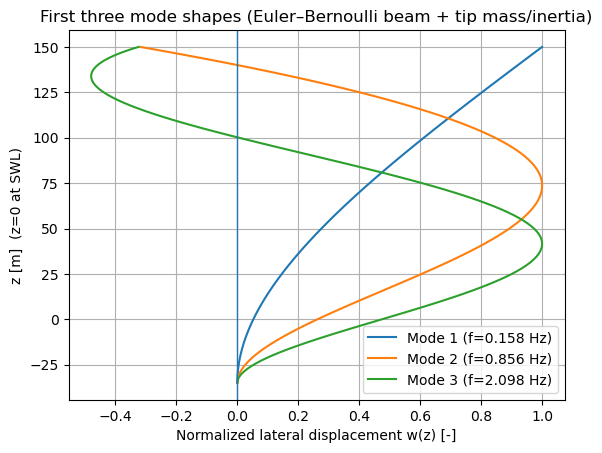

In [6]:
# ----------------------------
# Plot mode shapes (displacement) vs z
# ----------------------------
plt.figure()
for i in range(n_modes):
    plt.plot(modes_w[i], z, label=f"Mode {i+1} (f={freq[i]:.3f} Hz)")
plt.axvline(0, linewidth=1)
plt.xlabel("Normalized lateral displacement w(z) [-]")
plt.ylabel("z [m]  (z=0 at SWL)")
plt.title("First three mode shapes (Euler–Bernoulli beam + tip mass/inertia)")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Governing equations (FE form) reminder (for your report):
# M*qdd + K*q = f(t)
# With clamped BC at base and tip mass/inertia included in M.
# ----------------------------

Chosen wave period T = 12.00 s, omega = 0.5236 rad/s
SWL node index = 23, z=0.458 m
Top node index = 120, z=150.000 m
|w_hat(SWL)| = 3.776577e-03 m
|w_hat(Top)| = 2.318344e-02 m


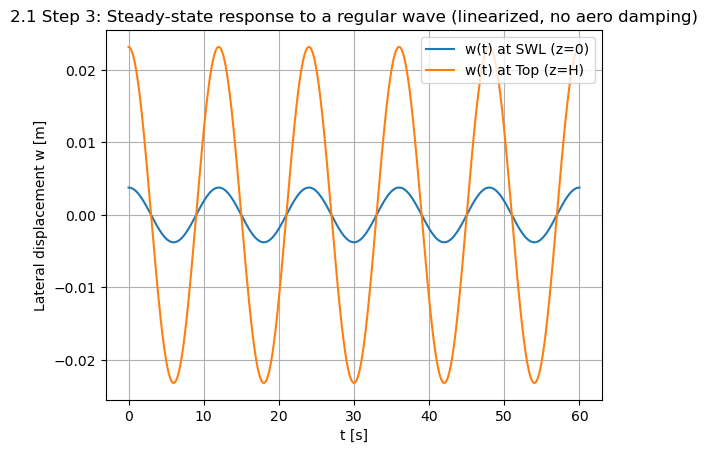

In [7]:
# ----------------------------
# 2.1 - Step 3: regular wave -> steady-state response (linearized)
# ----------------------------

# Geometry / given parameters (Table 2)
h = 35.0
H = 150.0
L = h + H

D = 8.0
t = 0.1

M_tip = 1000e3     # 1000 tons -> 1e6 kg
J_tip = 1.6e9      # kg m^2

# Material (explicit assumption; assignment says "Steel" but not the numbers)
E = 210e9
rho_steel = 7850.0

# Water / wave
rho_w = 1025.0
g = 9.81
Tp = 12.0          # choose Tp as suggested
omega = 2*np.pi/Tp
phi = 0.0          # wave phase (you can change)

# Regular wave height: not explicitly specified for step 3 in the PDF.
# Reasonable choice: use significant wave height as an example amplitude.
Hs = 6.0
a = Hs / 2.0       # wave amplitude

# Morison inertial coefficient (assumed; not provided in the PDF)
Cm = 2.0

# Hollow circular section
R_o = D/2.0
R_i = R_o - t
A = np.pi * (R_o**2 - R_i**2)
I = (np.pi/4.0) * (R_o**4 - R_i**4)
mu = rho_steel * A
EI = E * I

# FEM mesh
Ne = 120
Nn = Ne + 1
Le = L / Ne
ndof = 2 * Nn

# Node coordinates (z=0 at SWL, bottom at -h, top at H)
z_nodes = np.linspace(-h, H, Nn)

K = np.zeros((ndof, ndof))
M = np.zeros((ndof, ndof))

def beam_element_matrices(EI, mu, l):
    ke = (EI / l**3) * np.array([
        [ 12,   6*l, -12,   6*l],
        [ 6*l, 4*l**2, -6*l, 2*l**2],
        [-12,  -6*l,  12,  -6*l],
        [ 6*l, 2*l**2, -6*l, 4*l**2]
    ])
    me = (mu * l / 420.0) * np.array([
        [156,   22*l,   54,  -13*l],
        [22*l,  4*l**2, 13*l, -3*l**2],
        [54,    13*l,  156,  -22*l],
        [-13*l, -3*l**2, -22*l, 4*l**2]
    ])
    return ke, me

# Assemble structural M,K
for e in range(Ne):
    ke, me = beam_element_matrices(EI, mu, Le)
    n1, n2 = e, e+1
    dofs = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1])
    K[np.ix_(dofs, dofs)] += ke
    M[np.ix_(dofs, dofs)] += me

# Tip mass + rotary inertia at top node
dof_w_top = 2*(Nn-1)
dof_th_top = dof_w_top + 1
M[dof_w_top, dof_w_top] += M_tip
M[dof_th_top, dof_th_top] += J_tip

# Clamp at seabed: w=0, theta=0 at node 0
fixed = np.array([0, 1])
free = np.setdiff1d(np.arange(ndof), fixed)

K_ff = K[np.ix_(free, free)]
M_ff = M[np.ix_(free, free)]

# ----------------------------
# Wave kinematics (linear wave theory)
# Solve dispersion: omega^2 = g k tanh(k h)
# ----------------------------
def solve_dispersion(omega, h, g=9.81):
    # Newton-Raphson
    k = omega**2/g  # deep-water guess
    for _ in range(50):
        f = g*k*np.tanh(k*h) - omega**2
        df = g*np.tanh(k*h) + g*k*h*(1/np.cosh(k*h))**2
        k_new = k - f/df
        if abs(k_new - k) < 1e-12:
            break
        k = k_new
    return k

k = solve_dispersion(omega, h, g)

# Horizontal particle acceleration amplitude at position z (z<=0 in water)
# u(z,t) = a*omega * cosh(k(z+h))/sinh(kh) * cos(omega t - kx + phi)
# u_dot amplitude = a*omega^2 * cosh(k(z+h))/sinh(kh)
def u_ddot_amp(z):
    # z is negative in water column; z+h is in [0,h]
    return a * omega**2 * np.cosh(k*(z + h)) / np.sinh(k*h)

# Morison inertia force per unit length amplitude:
# f(z) = rho_w * Cm * (pi D^2/4) * u_ddot_amp(z)
A_disp = np.pi * D**2 / 4.0
def f_line_amp(z):
    return rho_w * Cm * A_disp * u_ddot_amp(z)

# ----------------------------
# Build harmonic load vector Fhat (complex amplitude)
# Using consistent nodal loads for (approximately) constant distributed load on each element:
# fe = p*l/12 * [6, l, 6, -l]  (for DOFs [w1,th1,w2,th2])
# ----------------------------
Fhat = np.zeros(ndof, dtype=complex)

for e in range(Ne):
    z1 = z_nodes[e]
    z2 = z_nodes[e+1]
    zmid = 0.5*(z1+z2)

    # Only submerged part contributes
    if zmid > 0.0:
        continue

    p = f_line_amp(zmid)  # N/m amplitude
    fe = (p * Le / 12.0) * np.array([6.0, Le, 6.0, -Le])

    # Add wave phase (and you could include exp(-ikx) if you model spatial variation)
    fe = fe * np.exp(1j*phi)

    n1, n2 = e, e+1
    dofs = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1])
    Fhat[dofs] += fe

Fhat_f = Fhat[free]

# ----------------------------
# Solve harmonic steady-state (NO damping here for step 3)
# (K - omega^2 M) qhat = Fhat
# ----------------------------
Dyn = (K_ff - (omega**2)*M_ff)

# Small numerical regularization to avoid singularity if omega hits an eigenfrequency
Dyn_reg = Dyn + 1e-9*np.max(np.abs(K_ff))*np.eye(Dyn.shape[0])

qhat_free = np.linalg.solve(Dyn_reg, Fhat_f)

qhat = np.zeros(ndof, dtype=complex)
qhat[free] = qhat_free

w_hat_nodes = qhat[0::2]  # complex displacement amplitude at nodes

# Indices for z=0 (SWL) and top z=H
i_swl = int(np.argmin(np.abs(z_nodes - 0.0)))
i_top = Nn - 1

print(f"Chosen wave period T = {Tp:.2f} s, omega = {omega:.4f} rad/s")
print(f"SWL node index = {i_swl}, z={z_nodes[i_swl]:.3f} m")
print(f"Top node index = {i_top}, z={z_nodes[i_top]:.3f} m")
print(f"|w_hat(SWL)| = {abs(w_hat_nodes[i_swl]):.6e} m")
print(f"|w_hat(Top)| = {abs(w_hat_nodes[i_top]):.6e} m")

# ----------------------------
# Time series over a few periods
# w(t) = Re{ w_hat * exp(i omega t) }
# ----------------------------
n_periods = 5
t = np.linspace(0, n_periods*Tp, 2000)

w_swl = np.real(w_hat_nodes[i_swl] * np.exp(1j*omega*t))
w_top = np.real(w_hat_nodes[i_top] * np.exp(1j*omega*t))

plt.figure()
plt.plot(t, w_swl, label="w(t) at SWL (z=0)")
plt.plot(t, w_top, label="w(t) at Top (z=H)")
plt.xlabel("t [s]")
plt.ylabel("Lateral displacement w [m]")
plt.title("2.1 Step 3: Steady-state response to a regular wave (linearized, no aero damping)")
plt.grid(True)
plt.legend()
plt.show()

SWL node z = 0.458 m, Top node z = 150.000 m
Component |w_hat(SWL)| [m]: [0.0006303183140042711, 0.0029858279781412958, 0.001930312197003707, 0.002243992380159444, 0.01692699137116244, 0.0004961500085138683]
Component |w_hat(Top)| [m]: [0.004545330442698836, 0.024116878841827758, 0.018438824583175605, 0.02741543421131938, 0.3034335137776101, 0.018519897152546216]


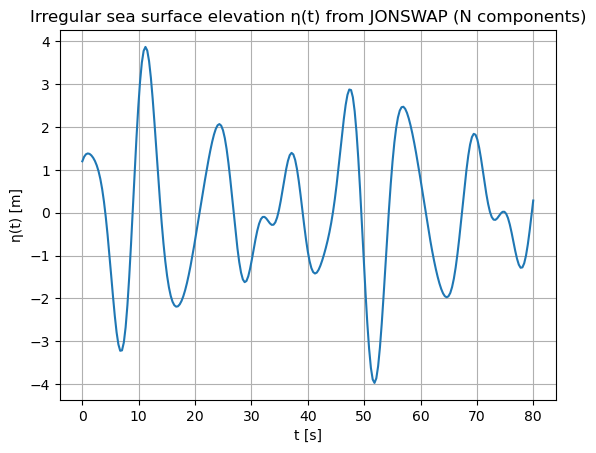

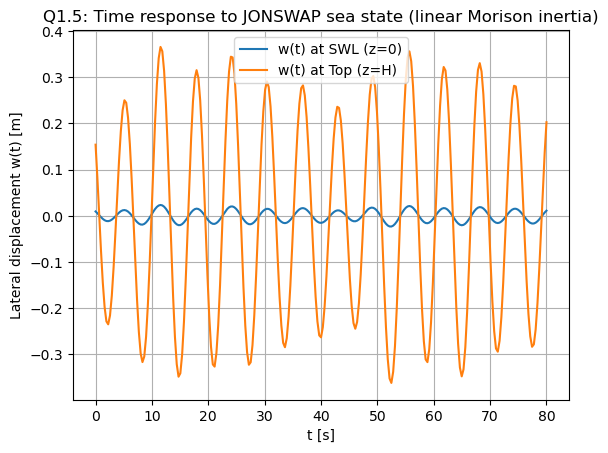

In [8]:
# =========================
# 0) Inputs (match your assignment choices)
# =========================
h = 35.0
H = 150.0
L = h + H

D = 8.0
t_wall = 0.1

M_tip = 1000e3
J_tip = 1.6e9

E = 210e9
rho_steel = 7850.0

rho_w = 1025.0
g = 9.81
Cm = 2.0  # assumed (not given); inertial Morison coefficient

Hs = 6.0
Tp = 12.0
fp = 1.0 / Tp

# FEM resolution
Ne = 120

# Optional numerical damping (set to 0.0 for "no damping")
zeta_struct = 0.0

# =========================
# 1) Your JONSWAP sea surface elevation eta(t)
# =========================
def jonswap(f, Hs, Tp, gamma=3.3):
    fp = 1.0 / Tp
    alpha = 0.0624 / (0.230 + 0.0336*gamma - 0.185*(1.9 + gamma)**-1)
    sigma = np.where(f <= fp, 0.07, 0.09)
    r = np.exp(-0.5 * ((f - fp) / (sigma * fp))**2)
    S = (alpha * Hs**2 * fp**4 * f**-5
         * np.exp(-1.25 * (fp / f)**4)
         * gamma**r)
    return S

# Sampling frequencies
N = 6
freqs_samp = np.linspace(0.75 * fp, 2.2 * fp, N)   # Hz
omegas = 2 * np.pi * freqs_samp                    # rad/s
df = freqs_samp[1] - freqs_samp[0]
S_samp = jonswap(freqs_samp, Hs, Tp)

# Time settings (same logic as you used)
T_max = 1.0 / freqs_samp[0]
t_end = 5 * T_max
dt = T_max / 50
t = np.arange(0, t_end + dt, dt)

# Irregular wave components from JONSWAP
amplitudes_eta = np.sqrt(2 * S_samp * df)  # amplitude of eta for each component
np.random.seed(42)
phases = np.random.uniform(0, 2*np.pi, N)

# Sea-surface elevation
eta = np.zeros_like(t)
for amp, omega_i, phi_i in zip(amplitudes_eta, omegas, phases):
    eta += amp * np.cos(omega_i * t + phi_i)

# =========================
# 2) FEM model (Euler-Bernoulli beam, w/theta DOFs)
# =========================
R_o = D/2.0
R_i = R_o - t_wall
A = np.pi * (R_o**2 - R_i**2)
I = (np.pi/4.0) * (R_o**4 - R_i**4)
mu = rho_steel * A
EI = E * I

Nn = Ne + 1
Le = L / Ne
ndof = 2 * Nn
z_nodes = np.linspace(-h, H, Nn)  # z=0 at SWL

K = np.zeros((ndof, ndof))
M = np.zeros((ndof, ndof))

def beam_element_matrices(EI, mu, l):
    ke = (EI / l**3) * np.array([
        [ 12,   6*l, -12,   6*l],
        [ 6*l, 4*l**2, -6*l, 2*l**2],
        [-12,  -6*l,  12,  -6*l],
        [ 6*l, 2*l**2, -6*l, 4*l**2]
    ])
    me = (mu * l / 420.0) * np.array([
        [156,   22*l,   54,  -13*l],
        [22*l,  4*l**2, 13*l, -3*l**2],
        [54,    13*l,  156,  -22*l],
        [-13*l, -3*l**2, -22*l, 4*l**2]
    ])
    return ke, me

for e in range(Ne):
    ke, me = beam_element_matrices(EI, mu, Le)
    n1, n2 = e, e+1
    dofs = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1])
    K[np.ix_(dofs, dofs)] += ke
    M[np.ix_(dofs, dofs)] += me

# tip mass + rotary inertia
dof_w_top = 2*(Nn-1)
dof_th_top = dof_w_top + 1
M[dof_w_top, dof_w_top] += M_tip
M[dof_th_top, dof_th_top] += J_tip

# clamp at seabed
fixed = np.array([0, 1])
free = np.setdiff1d(np.arange(ndof), fixed)
K_ff = K[np.ix_(free, free)]
M_ff = M[np.ix_(free, free)]

# Helper: dispersion solver per omega
def solve_dispersion(omega, h, g=9.81):
    k = omega**2 / g
    for _ in range(60):
        f = g*k*np.tanh(k*h) - omega**2
        df = g*np.tanh(k*h) + g*k*h*(1/np.cosh(k*h))**2
        k_new = k - f/df
        if abs(k_new - k) < 1e-12:
            break
        k = k_new
    return k

A_disp = np.pi * D**2 / 4.0

# Optional: simple proportional damping (Rayleigh-like, very light)
# Here we do a pragmatic constant modal-like damping by adding i*2*zeta*omega*M
# (Not exact Rayleigh, but common for harmonic response regularization.)
def dynamic_stiffness(omega, zeta=0.0):
    Ceff = 2.0*zeta*omega*M_ff
    return (K_ff - omega**2*M_ff) + 1j*omega*Ceff

# Build consistent nodal load vector for a constant distributed load p over element:
# fe = p*l/12 * [6, l, 6, -l]
def add_distributed_load_to_F(F, e, p):
    fe = (p * Le / 12.0) * np.array([6.0, Le, 6.0, -Le])
    n1, n2 = e, e+1
    dofs = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1])
    F[dofs] += fe

# Compute complex response for one wave component i
def component_response(omega_i, eta_amp_i, phase_i):
    k_i = solve_dispersion(omega_i, h, g)

    # Build complex harmonic load amplitude Fhat (including phase)
    Fhat = np.zeros(ndof, dtype=complex)

    for e in range(Ne):
        zmid = 0.5*(z_nodes[e] + z_nodes[e+1])

        # only submerged portion
        if zmid > 0.0:
            continue

        # horizontal particle acceleration amplitude at zmid:
        # u_ddot_amp = eta_amp * omega^2 * cosh(k(z+h))/sinh(kh)
        u_ddot_amp = eta_amp_i * omega_i**2 * np.cosh(k_i*(zmid + h)) / np.sinh(k_i*h)

        # Morison inertia force per unit length amplitude:
        p_amp = rho_w * Cm * A_disp * u_ddot_amp  # N/m

        # include random phase in complex amplitude
        p_complex = p_amp * np.exp(1j*phase_i)

        add_distributed_load_to_F(Fhat, e, p_complex)

    # Solve (K - w^2 M + i*w*Ceff) qhat = Fhat
    Dyn = dynamic_stiffness(omega_i, zeta=zeta_struct)

    # regularization (tiny) in case you land near resonance
    Dyn_reg = Dyn + 1e-10*np.max(np.abs(K_ff))*np.eye(Dyn.shape[0])

    qhat_free = np.linalg.solve(Dyn_reg, Fhat[free])
    qhat = np.zeros(ndof, dtype=complex)
    qhat[free] = qhat_free

    # return complex displacement at nodes
    return qhat[0::2]  # w-hat per node

# Indices for SWL and top
i_swl = int(np.argmin(np.abs(z_nodes - 0.0)))
i_top = Nn - 1

# =========================
# 3) Assemble time response w(t) at SWL and Top
# =========================
w_swl = np.zeros_like(t, dtype=float)
w_top = np.zeros_like(t, dtype=float)

# Also store component-wise complex amplitudes (optional)
w_hat_swl = []
w_hat_top = []

for omega_i, eta_amp_i, phase_i in zip(omegas, amplitudes_eta, phases):
    w_hat_nodes = component_response(omega_i, eta_amp_i, phase_i)

    w_hat_swl_i = w_hat_nodes[i_swl]
    w_hat_top_i = w_hat_nodes[i_top]
    w_hat_swl.append(w_hat_swl_i)
    w_hat_top.append(w_hat_top_i)

    # time contribution: Re{ w_hat * exp(i omega t) }
    w_swl += np.real(w_hat_swl_i * np.exp(1j*omega_i*t))
    w_top += np.real(w_hat_top_i * np.exp(1j*omega_i*t))

print(f"SWL node z = {z_nodes[i_swl]:.3f} m, Top node z = {z_nodes[i_top]:.3f} m")
print("Component |w_hat(SWL)| [m]:", [float(abs(x)) for x in w_hat_swl])
print("Component |w_hat(Top)| [m]:", [float(abs(x)) for x in w_hat_top])

# =========================
# 4) Plots: eta(t), w(t) at SWL/top
# =========================
plt.figure()
plt.plot(t, eta)
plt.xlabel("t [s]")
plt.ylabel("η(t) [m]")
plt.title("Irregular sea surface elevation η(t) from JONSWAP (N components)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, w_swl, label="w(t) at SWL (z=0)")
plt.plot(t, w_top, label="w(t) at Top (z=H)")
plt.xlabel("t [s]")
plt.ylabel("Lateral displacement w(t) [m]")
plt.title("Q1.5: Time response to JONSWAP sea state (linear Morison inertia)")
plt.grid(True)
plt.legend()
plt.show()

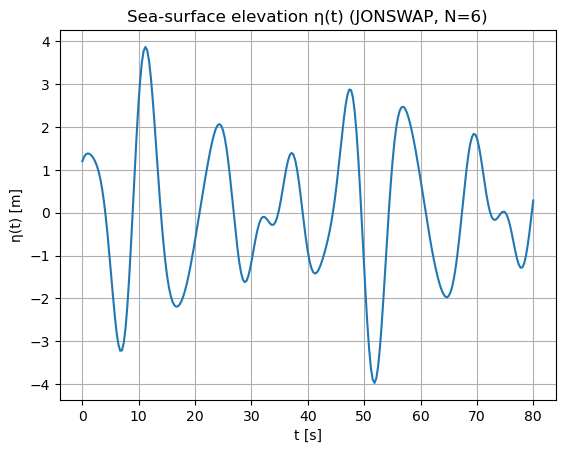

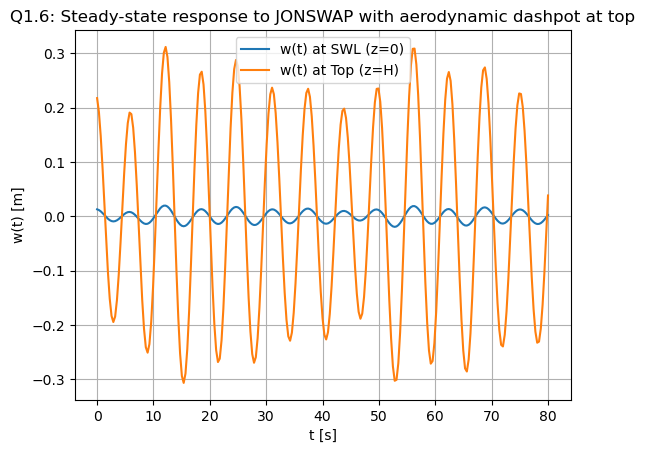

In [9]:
# =========================
# 0) Inputs
# =========================
h = 35.0
H = 150.0
L = h + H

D = 8.0
t_wall = 0.1

M_tip = 1000e3
J_tip = 1.6e9

E = 210e9
rho_steel = 7850.0

rho_w = 1025.0
g = 9.81
Cm = 2.0  # assumed; Morison inertia coefficient

# Aerodynamic damping (dashpot at top) - GIVEN in Table 2
c_dashpot = 30e3  # [N s/m] = 30 kN s/m

Hs = 6.0
Tp = 12.0
fp = 1.0 / Tp

Ne = 120

# =========================
# 1) Your JONSWAP sea surface elevation eta(t)
# =========================
def jonswap(f, Hs, Tp, gamma=3.3):
    fp = 1.0 / Tp
    alpha = 0.0624 / (0.230 + 0.0336*gamma - 0.185*(1.9 + gamma)**-1)
    sigma = np.where(f <= fp, 0.07, 0.09)
    r = np.exp(-0.5 * ((f - fp) / (sigma * fp))**2)
    S = (alpha * Hs**2 * fp**4 * f**-5
         * np.exp(-1.25 * (fp / f)**4)
         * gamma**r)
    return S

N = 6
freqs_samp = np.linspace(0.75 * fp, 2.2 * fp, N)   # Hz
omegas = 2 * np.pi * freqs_samp                    # rad/s
df = freqs_samp[1] - freqs_samp[0]
S_samp = jonswap(freqs_samp, Hs, Tp)

T_max = 1.0 / freqs_samp[0]
t_end = 5 * T_max
dt = T_max / 50
t = np.arange(0, t_end + dt, dt)

amplitudes_eta = np.sqrt(2 * S_samp * df)  # eta-component amplitude
np.random.seed(42)
phases = np.random.uniform(0, 2*np.pi, N)

eta = np.zeros_like(t)
for amp, omega_i, phi_i in zip(amplitudes_eta, omegas, phases):
    eta += amp * np.cos(omega_i * t + phi_i)

# =========================
# 2) FEM model (Euler-Bernoulli beam)
# =========================
R_o = D/2.0
R_i = R_o - t_wall
A = np.pi * (R_o**2 - R_i**2)
I = (np.pi/4.0) * (R_o**4 - R_i**4)
mu = rho_steel * A
EI = E * I

Nn = Ne + 1
Le = L / Ne
ndof = 2 * Nn
z_nodes = np.linspace(-h, H, Nn)  # z=0 at SWL

K = np.zeros((ndof, ndof))
M = np.zeros((ndof, ndof))
C = np.zeros((ndof, ndof))        # <-- NEW for 1.6

def beam_element_matrices(EI, mu, l):
    ke = (EI / l**3) * np.array([
        [ 12,   6*l, -12,   6*l],
        [ 6*l, 4*l**2, -6*l, 2*l**2],
        [-12,  -6*l,  12,  -6*l],
        [ 6*l, 2*l**2, -6*l, 4*l**2]
    ])
    me = (mu * l / 420.0) * np.array([
        [156,   22*l,   54,  -13*l],
        [22*l,  4*l**2, 13*l, -3*l**2],
        [54,    13*l,  156,  -22*l],
        [-13*l, -3*l**2, -22*l, 4*l**2]
    ])
    return ke, me

for e in range(Ne):
    ke, me = beam_element_matrices(EI, mu, Le)
    n1, n2 = e, e+1
    dofs = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1])
    K[np.ix_(dofs, dofs)] += ke
    M[np.ix_(dofs, dofs)] += me

# Tip mass + rotary inertia
dof_w_top = 2*(Nn-1)
dof_th_top = dof_w_top + 1
M[dof_w_top, dof_w_top] += M_tip
M[dof_th_top, dof_th_top] += J_tip

# Dashpot at top translation DOF (w at z=H)
C[dof_w_top, dof_w_top] += c_dashpot

# Boundary conditions: clamped at seabed
fixed = np.array([0, 1])
free = np.setdiff1d(np.arange(ndof), fixed)

K_ff = K[np.ix_(free, free)]
M_ff = M[np.ix_(free, free)]
C_ff = C[np.ix_(free, free)]

# Dispersion solver
def solve_dispersion(omega, h, g=9.81):
    k = omega**2 / g
    for _ in range(60):
        f = g*k*np.tanh(k*h) - omega**2
        df = g*np.tanh(k*h) + g*k*h*(1/np.cosh(k*h))**2
        k_new = k - f/df
        if abs(k_new - k) < 1e-12:
            break
        k = k_new
    return k

A_disp = np.pi * D**2 / 4.0

def add_distributed_load_to_F(F, e, p):
    fe = (p * Le / 12.0) * np.array([6.0, Le, 6.0, -Le])
    n1, n2 = e, e+1
    dofs = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1])
    F[dofs] += fe

def component_response_with_dashpot(omega_i, eta_amp_i, phase_i):
    k_i = solve_dispersion(omega_i, h, g)
    Fhat = np.zeros(ndof, dtype=complex)

    for e in range(Ne):
        zmid = 0.5*(z_nodes[e] + z_nodes[e+1])
        if zmid > 0.0:
            continue

        # u_ddot amplitude (linear wave theory)
        u_ddot_amp = eta_amp_i * omega_i**2 * np.cosh(k_i*(zmid + h)) / np.sinh(k_i*h)

        # Morison inertia force per unit length amplitude
        p_amp = rho_w * Cm * A_disp * u_ddot_amp
        p_complex = p_amp * np.exp(1j*phase_i)

        add_distributed_load_to_F(Fhat, e, p_complex)

    # (K + i*w*C - w^2*M) qhat = Fhat
    Dyn = (K_ff + 1j*omega_i*C_ff - (omega_i**2)*M_ff)

    # tiny regularization
    Dyn_reg = Dyn + 1e-10*np.max(np.abs(K_ff))*np.eye(Dyn.shape[0])

    qhat_free = np.linalg.solve(Dyn_reg, Fhat[free])
    qhat = np.zeros(ndof, dtype=complex)
    qhat[free] = qhat_free
    return qhat[0::2]  # w_hat at nodes

# Indices for SWL and top
i_swl = int(np.argmin(np.abs(z_nodes - 0.0)))
i_top = Nn - 1

# =========================
# 3) Assemble time response w(t) with superposition
# =========================
w_swl = np.zeros_like(t, dtype=float)
w_top = np.zeros_like(t, dtype=float)

for omega_i, eta_amp_i, phase_i in zip(omegas, amplitudes_eta, phases):
    w_hat_nodes = component_response_with_dashpot(omega_i, eta_amp_i, phase_i)
    w_swl += np.real(w_hat_nodes[i_swl] * np.exp(1j*omega_i*t))
    w_top += np.real(w_hat_nodes[i_top] * np.exp(1j*omega_i*t))

# =========================
# 4) Plots
# =========================
plt.figure()
plt.plot(t, eta)
plt.xlabel("t [s]")
plt.ylabel("η(t) [m]")
plt.title("Sea-surface elevation η(t) (JONSWAP, N=6)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, w_swl, label="w(t) at SWL (z=0)")
plt.plot(t, w_top, label="w(t) at Top (z=H)")
plt.xlabel("t [s]")
plt.ylabel("w(t) [m]")
plt.title("Q1.6: Steady-state response to JONSWAP with aerodynamic dashpot at top")
plt.grid(True)
plt.legend()
plt.show()